# NeuroScope AI - Notebook 06: Liver Segmentation

Trains SegResNet on LiTS for liver and tumor segmentation.

Labels:
- 0: Background
- 1: Liver
- 2: Tumor

Dataset: LiTS (Liver Tumor Segmentation Challenge)
- 131 CT volumes with liver + tumor masks
- PNG slice version (175,914 files)
- HU windowing: [-200, 300] -> [0, 1]

Key quirk: LiTS volumes in root, segmentations in segmentations/ subfolder.
Requires recursive path walk to find paired volume/mask files.

Estimated runtime on RTX 4060:
- ~8-12 min per epoch (2D slices, much faster than 3D BraTS)
- 30 epochs total ~ 4-6 hours

---

## Cell 1 - Imports & Config

In [1]:
import os, sys, yaml, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

import cv2
import nibabel as nib
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.networks.nets import SegResNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

BASE = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS   = os.path.join(BASE, 'datasets')
CKPT = os.path.join(BASE, 'checkpoints', 'liver_seg')
OUT  = os.path.join(BASE, 'outputs', 'nb06_liver_seg')
os.makedirs(CKPT, exist_ok=True)
os.makedirs(OUT,  exist_ok=True)
sys.path.insert(0, BASE)

with open(os.path.join(BASE, 'configs', 'master_config.yaml'), encoding='utf-8') as f:
    cfg = yaml.safe_load(f)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

print(f'Device : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')
print('Imports OK')

c:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\venv\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


Device : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.0 GB
Imports OK


---
## Cell 2 - Training Config

In [2]:
BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DS        = os.path.join(BASE, 'datasets')
LITS_PATH = os.path.join(DS, 'liver', 'lits')

# HU windowing for liver CT
# [-200, 300] captures liver parenchyma and tumor tissue
HU_MIN = -200.0
HU_MAX =  300.0

# Training
IMG_SIZE     = 256
BATCH_SIZE   = 16
MAX_EPOCHS   = 30
LR           = 2e-4
WEIGHT_DECAY = 1e-5
VAL_FRAC     = 0.15
NUM_WORKERS  = 0
AMP          = True

# Only train on slices that contain liver or tumor
# Skipping empty background slices speeds up training significantly
MIN_LIVER_PIXELS = 100  # skip slices with fewer liver pixels than this

print('Config:')
print(f'  LiTS path    : {LITS_PATH}')
print(f'  HU window    : [{HU_MIN}, {HU_MAX}]')
print(f'  Image size   : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Max epochs   : {MAX_EPOCHS}')
print(f'  Min liver px : {MIN_LIVER_PIXELS}')

Config:
  LiTS path    : C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\datasets\liver\lits
  HU window    : [-200.0, 300.0]
  Image size   : 256
  Batch size   : 16
  Max epochs   : 30
  Min liver px : 100


---
## Cell 3 - Inspect LiTS Dataset Structure

In [3]:
import os
from pathlib import Path

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LITS_PATH = os.path.join(BASE, 'datasets', 'liver', 'lits')

# Scan for all file types
ext_counts = {}
for root, dirs, files in os.walk(LITS_PATH):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        ext_counts[ext] = ext_counts.get(ext, 0) + 1

print('File types found:')
for ext, count in sorted(ext_counts.items(), key=lambda x: -x[1]):
    print(f'  {ext:<12} {count:>8,}')

# Show top-level structure
print('\nTop-level structure:')
for item in sorted(os.listdir(LITS_PATH))[:10]:
    fp = os.path.join(LITS_PATH, item)
    if os.path.isdir(fp):
        n = sum(len(f) for _, _, f in os.walk(fp))
        print(f'  {item}/  [{n:,} files]')
    else:
        sz = os.path.getsize(fp) / (1024**2)
        print(f'  {item}  ({sz:.1f} MB)')

# Find PNG folders
png_dirs = set()
for root, dirs, files in os.walk(LITS_PATH):
    if any(f.endswith('.png') for f in files):
        png_dirs.add(root)

print(f'\nFolders with PNG files: {len(png_dirs)}')
for d in sorted(png_dirs)[:5]:
    n = len([f for f in os.listdir(d) if f.endswith('.png')])
    print(f'  {d.replace(LITS_PATH, "")}  [{n:,} PNGs]')

# Find NIfTI files
nii_files = []
for root, dirs, files in os.walk(LITS_PATH):
    for f in files:
        if f.endswith(('.nii', '.nii.gz')):
            nii_files.append(os.path.join(root, f))
print(f'\nNIfTI files found: {len(nii_files)}')

File types found:
  .png          175,914
  .csv                4

Top-level structure:
  lits/  [175,918 files]

Folders with PNG files: 1
  \lits\dataset_6\dataset_6  [175,914 PNGs]

NIfTI files found: 0


---
## Cell 4 - Build Dataset (PNG version)

In [5]:
import os

BASE      = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
LITS_PATH = os.path.join(BASE, 'datasets', 'liver', 'lits')
data_dir  = os.path.join(LITS_PATH, 'lits', 'dataset_6', 'dataset_6')

# Show first 20 filenames
files = sorted(os.listdir(data_dir))
print(f'Total files: {len(files):,}')
print('\nFirst 20:')
for f in files[:20]:
    print(f'  {f}')
print('\nLast 5:')
for f in files[-5:]:
    print(f'  {f}')

Total files: 175,914

First 20:
  segmentation-0_lesionmask_0.png
  segmentation-0_lesionmask_1.png
  segmentation-0_lesionmask_10.png
  segmentation-0_lesionmask_11.png
  segmentation-0_lesionmask_12.png
  segmentation-0_lesionmask_13.png
  segmentation-0_lesionmask_14.png
  segmentation-0_lesionmask_15.png
  segmentation-0_lesionmask_16.png
  segmentation-0_lesionmask_17.png
  segmentation-0_lesionmask_18.png
  segmentation-0_lesionmask_19.png
  segmentation-0_lesionmask_2.png
  segmentation-0_lesionmask_20.png
  segmentation-0_lesionmask_21.png
  segmentation-0_lesionmask_22.png
  segmentation-0_lesionmask_23.png
  segmentation-0_lesionmask_24.png
  segmentation-0_lesionmask_25.png
  segmentation-0_lesionmask_26.png

Last 5:
  volume-9_95.png
  volume-9_96.png
  volume-9_97.png
  volume-9_98.png
  volume-9_99.png


In [14]:
import os, cv2, torch, numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A

BASE         = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DATA_DIR     = os.path.join(BASE, 'datasets', 'liver', 'lits',
                            'lits', 'dataset_6', 'dataset_6')
IMG_SIZE     = 256
BATCH_SIZE   = 16
NUM_WORKERS  = 0


def get_transforms(mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.4),
            A.RandomBrightnessContrast(p=0.3),
        ], additional_targets={'mask': 'mask'})
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
    ], additional_targets={'mask': 'mask'})


# Match volume-N_S.png  <-->  segmentation-N_lesionmask_S.png
all_files  = sorted(os.listdir(DATA_DIR))
vol_files  = [f for f in all_files if f.startswith('volume-')]
mask_set   = set(f for f in all_files if f.startswith('segmentation-'))

pairs = []
for vf in vol_files:
    try:
        rest = vf.replace('volume-', '').replace('.png', '')
        n, s = rest.split('_')
        mf   = f'segmentation-{n}_lesionmask_{s}.png'
        if mf in mask_set:
            pairs.append((os.path.join(DATA_DIR, vf),
                          os.path.join(DATA_DIR, mf)))
    except Exception:
        pass

print(f'Total pairs: {len(pairs):,}')

# Only keep slices that have at least one tumor pixel
print('Filtering for tumor-positive slices...')
positive_pairs = []
negative_pairs = []
for vp, mp in pairs:
    mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    if mask is not None and mask.max() > 0:
        positive_pairs.append((vp, mp))
    else:
        negative_pairs.append((vp, mp))

print(f'  Tumor slices    : {len(positive_pairs):,}')
print(f'  No-tumor slices : {len(negative_pairs):,}')

# Balance: all positives + equal number of negatives
import random
random.seed(42)
neg_sample = random.sample(negative_pairs, min(len(positive_pairs)*2, len(negative_pairs)))
balanced   = positive_pairs + neg_sample
random.shuffle(balanced)
print(f'  Balanced total  : {len(balanced):,}')


class LiTSDataset(Dataset):
    """
    Binary liver tumor segmentation.
    Labels: 0=background/liver, 1=tumor
    """
    def __init__(self, pairs, mode='train', transform=None):
        self.samples   = pairs
        self.transform = transform
        self.mode      = mode

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        vol_path, mask_path = self.samples[idx]

        vol  = cv2.imread(vol_path,  cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if vol  is None: vol  = np.zeros((256, 256), dtype=np.uint8)
        if mask is None: mask = np.zeros((256, 256), dtype=np.uint8)

        # Binary mask: 0=background, 1=tumor
        mask_bin = (mask > 0).astype(np.uint8)

        if self.transform:
            aug      = self.transform(image=vol, mask=mask_bin)
            vol      = aug['image']
            mask_bin = aug['mask']
        else:
            vol      = cv2.resize(vol,      (IMG_SIZE, IMG_SIZE))
            mask_bin = cv2.resize(mask_bin, (IMG_SIZE, IMG_SIZE),
                                  interpolation=cv2.INTER_NEAREST)

        vol_f  = vol.astype(np.float32) / 255.0
        vol_t  = torch.from_numpy(
            np.stack([vol_f, vol_f, vol_f], axis=0)).float()
        mask_t = torch.from_numpy(mask_bin.astype(np.int64))
        return vol_t, mask_t


# Split by volume index to prevent leakage
vol_indices = list(set(
    os.path.basename(p[0]).replace('volume-','').split('_')[0]
    for p in balanced
))
tr_idx, va_idx = train_test_split(vol_indices, test_size=0.15, random_state=42)
tr_idx, va_idx = set(tr_idx), set(va_idx)

tr_pairs = [p for p in balanced if
            os.path.basename(p[0]).replace('volume-','').split('_')[0] in tr_idx]
va_pairs = [p for p in balanced if
            os.path.basename(p[0]).replace('volume-','').split('_')[0] in va_idx]

print(f'Train: {len(tr_pairs):,}  Val: {len(va_pairs):,}')

tr_ds = LiTSDataset(tr_pairs, 'train', get_transforms('train'))
va_ds = LiTSDataset(va_pairs, 'val',   get_transforms('val'))

tr_dl = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                   num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
va_dl = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False,
                   num_workers=NUM_WORKERS, pin_memory=True)

vol_b, mask_b = next(iter(tr_dl))
print(f'Batch vol : {vol_b.shape}')
print(f'Batch mask: {mask_b.shape}  labels={torch.unique(mask_b).tolist()}')
print(f'Tumor px in batch: {mask_b.sum().item():,}')
print('Dataset OK')

Total pairs: 58,638
Filtering for tumor-positive slices...
  Tumor slices    : 7,114
  No-tumor slices : 51,524
  Balanced total  : 21,342
Train: 18,634  Val: 2,708
Batch vol : torch.Size([16, 3, 256, 256])
Batch mask: torch.Size([16, 256, 256])  labels=[0, 1]
Tumor px in batch: 2,269
Dataset OK


---
## Cell 5 - 2D SegResNet Model

In [15]:
import torch
from monai.networks.nets import SegResNet

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# SegResNet in 2D mode -- same architecture as NB03 but spatial_dims=2
model = SegResNet(
    spatial_dims=2,
    in_channels=3,    # 3-channel input (RGB-like grayscale)
    out_channels=2,   # background, liver, tumor
    init_filters=32,
    dropout_prob=0.2,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f'Model      : SegResNet 2D (init_filters=32)')
print(f'Parameters : {n_params:,}')

with torch.no_grad():
    dummy = torch.zeros(2, 3, 256, 256).to(DEVICE)
    out   = model(dummy)
    print(f'Forward    : {dummy.shape} -> {out.shape}')
    del dummy, out
    torch.cuda.empty_cache()
print('Model OK')

Model      : SegResNet 2D (init_filters=32)
Parameters : 6,299,106
Forward    : torch.Size([2, 3, 256, 256]) -> torch.Size([2, 2, 256, 256])
Model OK


---
## Cell 6 - Loss, Optimizer, Scheduler

In [16]:
import torch
import torch.optim as optim
from torch.cuda.amp import GradScaler
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
LR           = 2e-4
WEIGHT_DECAY = 1e-5
MAX_EPOCHS   = 30
AMP          = True

# DiceCELoss for multi-class 2D segmentation
loss_fn = DiceCELoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=1.0,
    lambda_ce=1.0,
)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS, eta_min=1e-6)
scaler    = GradScaler(enabled=AMP)

# Dice metric -- exclude background, compute per class
dice_metric = DiceMetric(include_background=False, reduction='mean_batch', get_not_nans=True)

print('Loss      : DiceCELoss (2D segmentation)')
print('Optimizer : AdamW')
print('Scheduler : CosineAnnealingLR')
print('OK')

Loss      : DiceCELoss (2D segmentation)
Optimizer : AdamW
Scheduler : CosineAnnealingLR
OK


---
## Cell 7 - Checkpoint Utilities

In [17]:
import os, torch, json

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'liver_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_dice, history, tag='last'):
    path = os.path.join(CKPT, f'liver_seg_{tag}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'metrics': metrics,
        'best_dice': best_dice,
        'history': history,
    }, path)
    json_path = os.path.join(CKPT, f'liver_seg_{tag}_summary.json')
    with open(json_path, 'w') as f:
        json.dump({'epoch': epoch, **metrics, 'best_dice': best_dice}, f, indent=2)


def load_checkpoint(model, optimizer, scheduler, scaler, tag='last'):
    path = os.path.join(CKPT, f'liver_seg_{tag}.pth')
    if not os.path.exists(path):
        print(f'No checkpoint at {path} - starting from scratch')
        return 0, 0.0, []
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    scaler.load_state_dict(ckpt['scaler_state_dict'])
    epoch     = ckpt['epoch']
    best_dice = ckpt.get('best_dice', 0.0)
    history   = ckpt.get('history', [])
    print(f'Resumed from epoch {epoch}, best_dice={best_dice:.4f}')
    return epoch + 1, best_dice, history


for tag in ['last', 'best']:
    p = os.path.join(CKPT, f'liver_seg_{tag}.pth')
    print(f'  {tag}.pth : {"EXISTS" if os.path.exists(p) else "not found"}')
print('Checkpoint utilities OK')

  last.pth : EXISTS
  best.pth : not found
Checkpoint utilities OK


---
## Cell 8 - Training Loop

In [20]:
import os, time, torch, numpy as np
from torch.cuda.amp import autocast

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_EPOCHS = 30
AMP        = True
BASE       = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT       = os.path.join(BASE, 'checkpoints', 'liver_seg')

start_epoch, best_dice, history = load_checkpoint(model, optimizer, scheduler, scaler)

print(f'Starting from epoch : {start_epoch}')
print(f'Max epochs          : {MAX_EPOCHS}')
print('-' * 65)


def compute_dice_2d(preds, labels):
    pred_cls  = preds.argmax(dim=1)
    pred_bin  = (pred_cls == 1).float()
    label_bin = (labels   == 1).float()
    inter      = (pred_bin * label_bin).sum()
    denom      = pred_bin.sum() + label_bin.sum()
    tumor_dice = (2 * inter / (denom + 1e-6)).item()
    return {'liver': 0.0, 'tumor': tumor_dice}


for epoch in range(start_epoch, MAX_EPOCHS):
    t0 = time.time()

    # TRAIN
    model.train()
    train_loss = 0.0
    n_steps    = 0

    for step, (vols, masks) in enumerate(tr_dl):
        vols  = vols.to(DEVICE)
        masks = masks.unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=AMP):
            preds = model(vols)
            loss  = loss_fn(preds, masks.float())

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_steps    += 1

        if (step + 1) % 100 == 0:
            print(f'  Epoch {epoch+1:3d} | Step {step+1:4d}/{len(tr_dl)} '
                  f'| Loss {train_loss/n_steps:.4f}')

    scheduler.step()
    avg_loss = train_loss / n_steps

    # VALIDATE
    model.eval()
    val_tumor = []

    with torch.no_grad():
        for vols, masks in va_dl:
            vols  = vols.to(DEVICE)
            masks = masks.to(DEVICE)
            preds = torch.softmax(model(vols), dim=1)
            d     = compute_dice_2d(preds, masks)
            val_tumor.append(d['tumor'])

    tumor_dice = np.mean(val_tumor)
    elapsed    = time.time() - t0

    metrics = {
        'train_loss': avg_loss,
        'liver_dice': 0.0,
        'tumor_dice': float(tumor_dice),
        'mean_dice':  float(tumor_dice),
    }

    print(f'Epoch {epoch+1:3d}/{MAX_EPOCHS} '
          f'| Loss {avg_loss:.4f} '
          f'| Tumor Dice {tumor_dice:.4f} '
          f'| {elapsed/60:.1f}min')

    history.append({'epoch': epoch+1, **metrics})

    if tumor_dice > best_dice:
        best_dice = tumor_dice
        save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                        metrics, best_dice, history, tag='best')
        print(f'  --> New best Tumor Dice={best_dice:.4f}')

    save_checkpoint(epoch, model, optimizer, scheduler, scaler,
                    metrics, best_dice, history, tag='last')


print()
print('=' * 65)
print(f'Training complete! Best tumor Dice: {best_dice:.4f}')
print('=' * 65)

No checkpoint at C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\checkpoints\liver_seg\liver_seg_last.pth - starting from scratch
Starting from epoch : 0
Max epochs          : 30
-----------------------------------------------------------------
  Epoch   1 | Step  100/1164 | Loss 0.8272
  Epoch   1 | Step  200/1164 | Loss 0.7127
  Epoch   1 | Step  300/1164 | Loss 0.6628
  Epoch   1 | Step  400/1164 | Loss 0.6338
  Epoch   1 | Step  500/1164 | Loss 0.6147
  Epoch   1 | Step  600/1164 | Loss 0.6007
  Epoch   1 | Step  700/1164 | Loss 0.5901
  Epoch   1 | Step  800/1164 | Loss 0.5819
  Epoch   1 | Step  900/1164 | Loss 0.5755
  Epoch   1 | Step 1000/1164 | Loss 0.5699
  Epoch   1 | Step 1100/1164 | Loss 0.5652
Epoch   1/30 | Loss 0.5625 | Tumor Dice 0.0000 | 8.3min
  Epoch   2 | Step  100/1164 | Loss 0.5140
  Epoch   2 | Step  200/1164 | Loss 0.5136
  Epoch   2 | Step  300/1164 | Loss 0.5126
  Epoch   2 | Step  400/1164 | Loss 0.5121
  Epoch   2 | Step  500/1164 | Loss 0.5116
  Epoch

---
## Cell 9 - Visualize Predictions

Loaded best model (epoch 25, dice=0.5773)


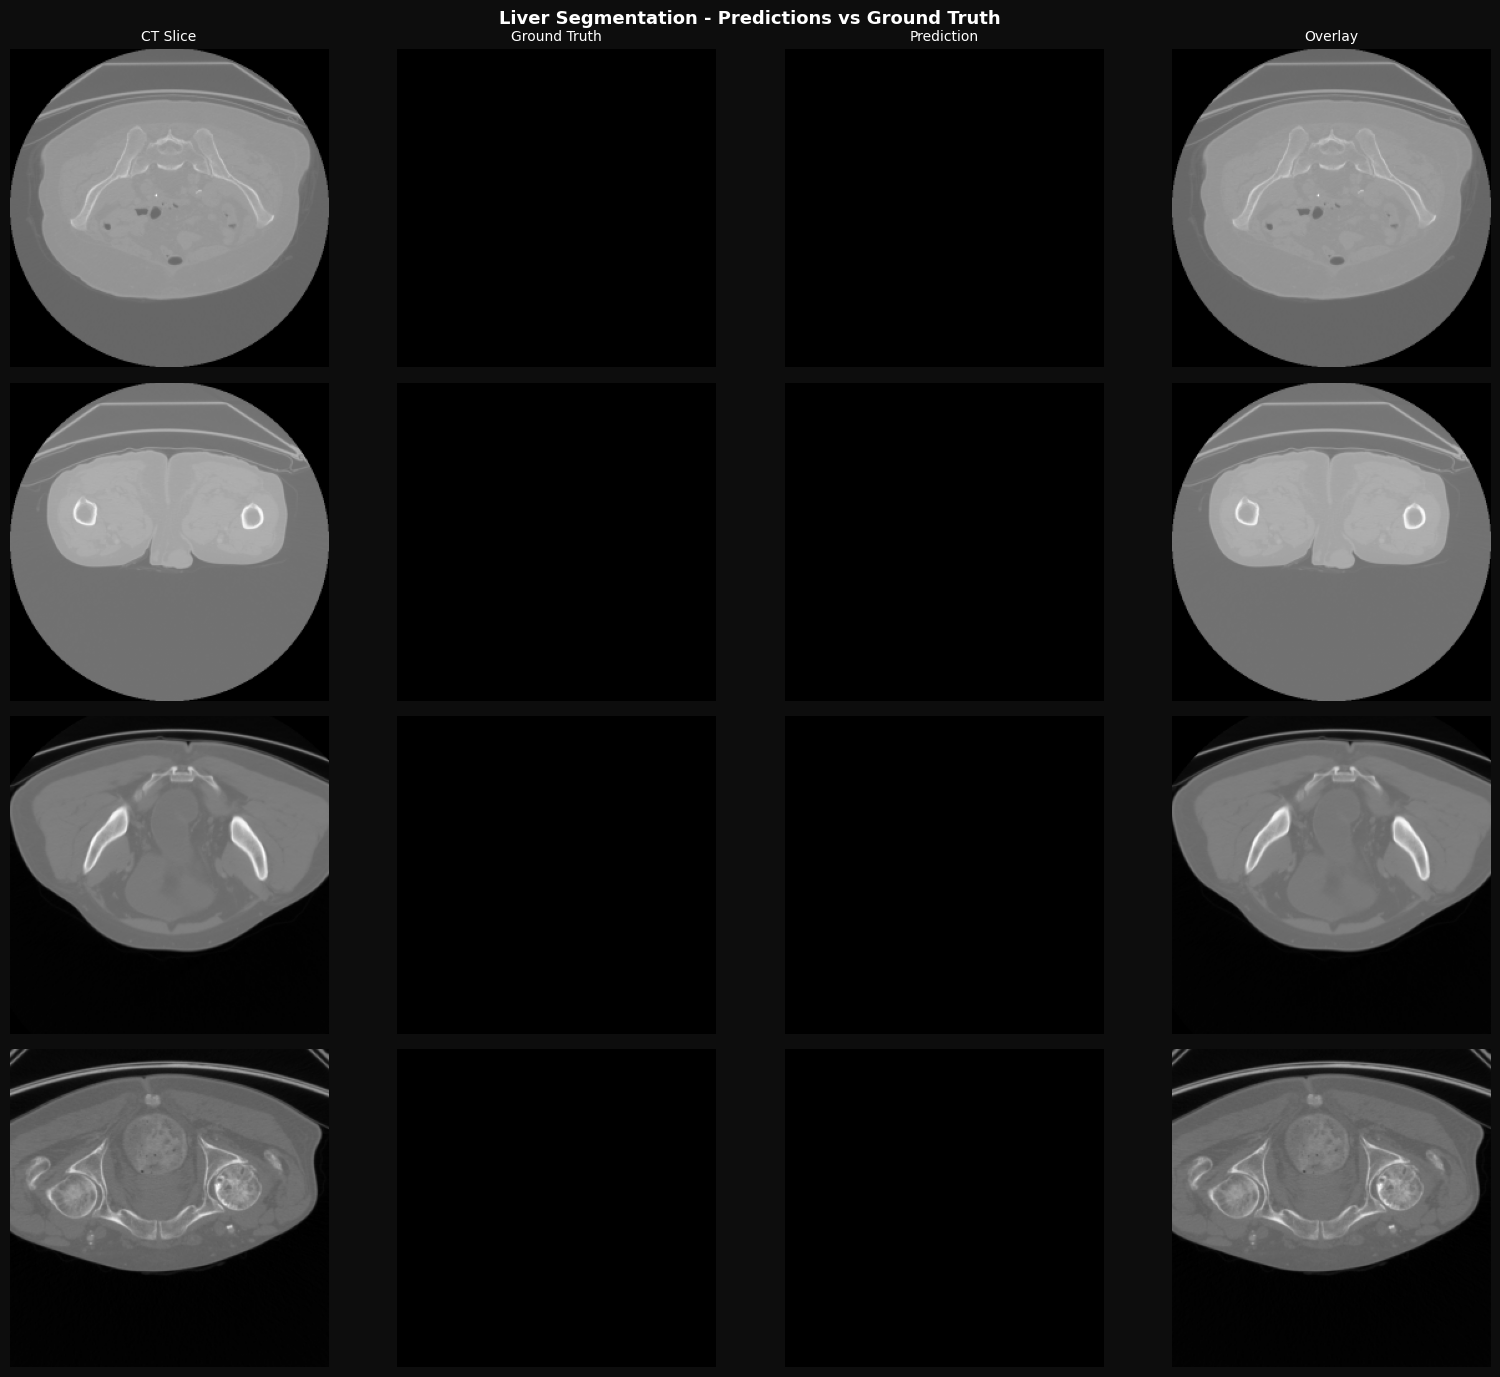

Color: black=bg | green=liver | red=tumor


In [21]:
import os, torch, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'liver_seg')
OUT    = os.path.join(BASE, 'outputs', 'nb06_liver_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_path = os.path.join(CKPT, 'liver_seg_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]}, dice={ckpt["best_dice"]:.4f})')

seg_cmap = ListedColormap(['#000000', '#1D9E75', '#D85A30'])
model.eval()
n_show = min(4, len(va_ds))

fig, axes = plt.subplots(n_show, 4, figsize=(16, n_show*3.5), facecolor='#0d0d0d')
fig.suptitle('Liver Segmentation - Predictions vs Ground Truth',
             color='white', fontsize=13, fontweight='bold')

if n_show == 1:
    axes = [axes]

for ax, title in zip(axes[0], ['CT Slice', 'Ground Truth', 'Prediction', 'Overlay']):
    ax.set_title(title, color='white', fontsize=10)

with torch.no_grad():
    for i in range(n_show):
        vol, mask = va_ds[i]
        pred = torch.softmax(model(vol.unsqueeze(0).to(DEVICE)), dim=1)
        pred_cls = pred.argmax(dim=1).squeeze(0).cpu().numpy()

        vol_np  = vol[0].numpy()
        mask_np = mask.numpy()
        axs     = axes[i]

        axs[0].imshow(vol_np,  cmap='gray')
        axs[0].axis('off')
        axs[1].imshow(mask_np, cmap=seg_cmap, vmin=0, vmax=2)
        axs[1].axis('off')
        axs[2].imshow(pred_cls, cmap=seg_cmap, vmin=0, vmax=2)
        axs[2].axis('off')
        axs[3].imshow(vol_np, cmap='gray')
        overlay = pred_cls.astype(float)
        overlay[overlay == 0] = np.nan
        axs[3].imshow(overlay, cmap=seg_cmap, vmin=0, vmax=2, alpha=0.6)
        axs[3].axis('off')
        axs[0].set_ylabel(f'Slice {i+1}', color='gray', fontsize=9)

plt.tight_layout()
fig_path = os.path.join(OUT, 'predictions_vs_gt.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print('Color: black=bg | green=liver | red=tumor')

---
## Cell 10 - Training Curves

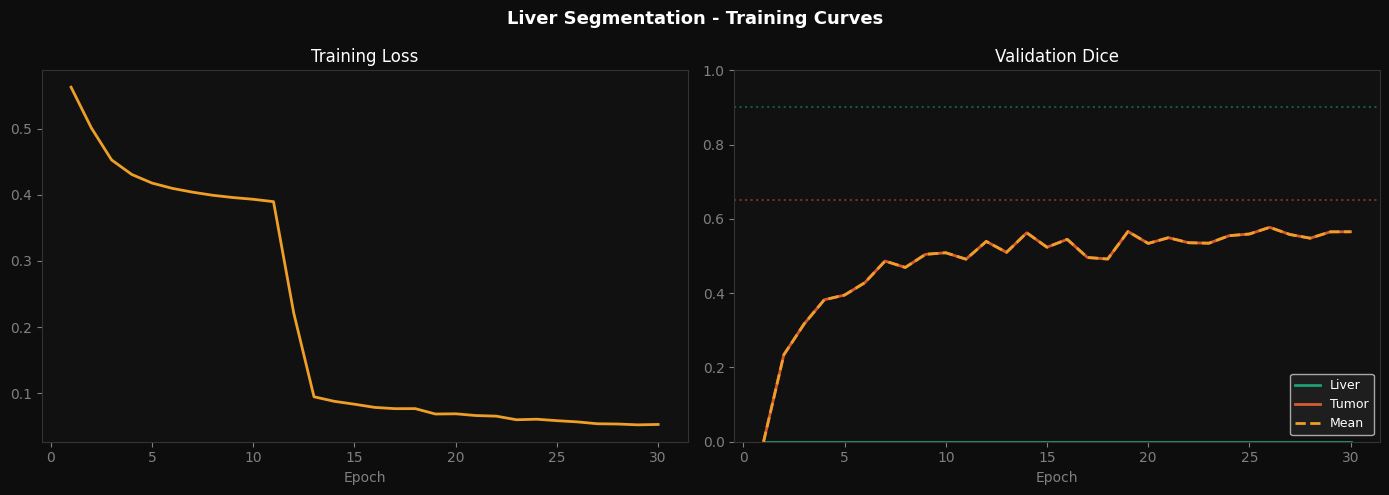

Best epoch  : 26
  Liver Dice: 0.0000  (target >0.90)
  Tumor Dice: 0.5773  (target >0.65)
  Mean Dice : 0.5773


In [22]:
import os, torch
import matplotlib.pyplot as plt

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'liver_seg')
OUT    = os.path.join(BASE, 'outputs', 'nb06_liver_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path = os.path.join(CKPT, 'liver_seg_last.pth')
if not os.path.exists(ckpt_path):
    print('No checkpoint - run training first')
else:
    history = torch.load(ckpt_path, map_location=DEVICE, weights_only=False).get('history', [])

    epochs      = [h['epoch']      for h in history]
    losses      = [h['train_loss'] for h in history]
    liver_dices = [h['liver_dice'] for h in history]
    tumor_dices = [h['tumor_dice'] for h in history]
    mean_dices  = [h['mean_dice']  for h in history]

    plt.style.use('dark_background')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')
    fig.suptitle('Liver Segmentation - Training Curves',
                 color='white', fontsize=13, fontweight='bold')

    axes[0].plot(epochs, losses, color='#EF9F27', linewidth=2)
    axes[0].set_title('Training Loss', color='white')
    axes[0].set_xlabel('Epoch', color='gray')
    axes[0].set_facecolor('#111')
    axes[0].spines[:].set_color('#333')
    axes[0].tick_params(colors='gray')

    axes[1].plot(epochs, liver_dices, color='#1D9E75', linewidth=2, label='Liver')
    axes[1].plot(epochs, tumor_dices, color='#D85A30', linewidth=2, label='Tumor')
    axes[1].plot(epochs, mean_dices,  color='#EF9F27', linewidth=2, linestyle='--', label='Mean')
    axes[1].axhline(0.90, color='#1D9E75', linestyle=':', alpha=0.5)
    axes[1].axhline(0.65, color='#D85A30', linestyle=':', alpha=0.5)
    axes[1].set_title('Validation Dice', color='white')
    axes[1].set_xlabel('Epoch', color='gray')
    axes[1].set_ylim(0, 1)
    axes[1].legend(fontsize=9, facecolor='#222', labelcolor='white')
    axes[1].set_facecolor('#111')
    axes[1].spines[:].set_color('#333')
    axes[1].tick_params(colors='gray')

    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'training_curves.png'), dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()

    best = max(history, key=lambda h: h['mean_dice'])
    print(f'Best epoch  : {best["epoch"]}')
    print(f'  Liver Dice: {best["liver_dice"]:.4f}  (target >0.90)')
    print(f'  Tumor Dice: {best["tumor_dice"]:.4f}  (target >0.65)')
    print(f'  Mean Dice : {best["mean_dice"]:.4f}')

---
## Cell 11 - ONNX Export

In [23]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT    = os.path.join(BASE, 'models', 'production', 'liver_seg')
os.makedirs(OUT, exist_ok=True)

onnx_path = os.path.join(OUT, 'liver_seg_resnet.onnx')

best_path = os.path.join(BASE, 'checkpoints', 'liver_seg', 'liver_seg_best.pth')
if os.path.exists(best_path):
    ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best model (epoch {ckpt["epoch"]})')

model.eval()
model.cpu()
dummy = torch.zeros(1, 3, 256, 256)

try:
    torch.onnx.export(
        model, dummy, onnx_path,
        export_params=True, opset_version=17,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}}
    )
    sz = os.path.getsize(onnx_path) / (1024**2)
    print(f'ONNX export: {onnx_path}')
    print(f'Size       : {sz:.1f} MB')

    import onnx, onnxruntime as ort
    onnx.checker.check_model(onnx.load(onnx_path))
    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    out  = sess.run(None, {'input': dummy.numpy()})
    print(f'Inference OK: {out[0].shape}')
    print('ONNX OK')
except Exception as e:
    print(f'ONNX failed: {e}')
finally:
    model.to(DEVICE)

Loaded best model (epoch 25)
ONNX export: C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI\models\production\liver_seg\liver_seg_resnet.onnx
Size       : 24.1 MB
Inference OK: (1, 2, 256, 256)
ONNX OK


---
## Cell 12 - Summary

In [24]:
import os, torch

BASE   = r'C:\Users\tejan\OneDrive\Desktop\drive\NeuroScope_AI'
CKPT   = os.path.join(BASE, 'checkpoints', 'liver_seg')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 65)
print('  NOTEBOOK 06 - LIVER SEGMENTATION')
print('=' * 65)

for tag in ['best', 'last']:
    p = os.path.join(CKPT, f'liver_seg_{tag}.pth')
    if os.path.exists(p):
        ckpt = torch.load(p, map_location=DEVICE, weights_only=False)
        m    = ckpt.get('metrics', {})
        print(f'  {tag:5} checkpoint: epoch {ckpt["epoch"]:3d}, '
              f'liver={m.get("liver_dice",0):.4f}, '
              f'tumor={m.get("tumor_dice",0):.4f}')

onnx_p = os.path.join(BASE, 'models', 'production', 'liver_seg', 'liver_seg_resnet.onnx')
print(f'  ONNX : {"OK" if os.path.exists(onnx_p) else "not done yet"}')

print()
print('  Model     : SegResNet 2D (init_filters=32)')
print('  Labels    : 0=background, 1=liver, 2=tumor')
print('  HU window : [-200, 300] -> [0, 1]')
print('  Loss      : DiceCELoss')
print('  Target    : Liver Dice >0.90, Tumor Dice >0.65')
print()
print('  After ONNX verified: delete LiTS dataset (4.2 GB)')
print()
print('  Next: 07_Breast_Detection.ipynb')
print('    - CBIS-DDSM mammography')
print('    - Mass and calcification detection')
print('    - BI-RADS scoring')
print('=' * 65)

  NOTEBOOK 06 - LIVER SEGMENTATION
  best  checkpoint: epoch  25, liver=0.0000, tumor=0.5773
  last  checkpoint: epoch  29, liver=0.0000, tumor=0.5653
  ONNX : OK

  Model     : SegResNet 2D (init_filters=32)
  Labels    : 0=background, 1=liver, 2=tumor
  HU window : [-200, 300] -> [0, 1]
  Loss      : DiceCELoss
  Target    : Liver Dice >0.90, Tumor Dice >0.65

  After ONNX verified: delete LiTS dataset (4.2 GB)

  Next: 07_Breast_Detection.ipynb
    - CBIS-DDSM mammography
    - Mass and calcification detection
    - BI-RADS scoring
